# `mosaic(bounds=...)` — Sentinel-2 mosaics for arbitrary bounding boxes

Instead of passing an MGRS tile via `grid_id`, you can pass a `bounds` tuple to mosaic any rectangular area, including ones that cross MGRS tile boundaries. Scenes from intersecting tiles are pulled and reprojected onto a common UTM grid via stackstac in one step.

This notebook shows: a basic bounds call, a non-square AOI, a lower-resolution mosaic with bilinear resampling, and a cross-tile AOI.

In [1]:
from pathlib import Path

from matplotlib import pyplot as plt

from s2mosaic import mosaic

## 1. Basic usage — small bounds in EPSG:4326

Bounds are `(minx, miny, maxx, maxy)`. Default `bounds_crs=4326`, so this is a lon/lat box. Output CRS is auto-picked from the bbox centroid (UTM zone 50S here).

In [2]:
# ~5km AOI near Perth, WA
bounds = (115.83, -31.97, 115.91, -31.94)

array, profile = mosaic(
    bounds=bounds,
    start_year=2023,
    start_month=6,
    start_day=1,
    duration_months=2,
    required_bands=["B04", "B03", "B02"],
    mosaic_method="percentile",
    percentile_value=50,
)

print(f"Shape: {array.shape}")
print(f"CRS:   {profile['crs']}")
print(f"Pixel: {profile['transform'].a}m")

/Users/nick/Documents/Work Code/S2Mosaic/.venv/lib/python3.11/site-packages/omnicloudmask/cloud_mask.py:274: UserWarning: Patch size too large, reducing to 171 and overlap to 85.
  patch_overlap, patch_size = check_patch_size(


Shape: (3, 341, 760)
CRS:   EPSG:32750
Pixel: 10.0m


(np.float64(-0.5), np.float64(759.5), np.float64(340.5), np.float64(-0.5))

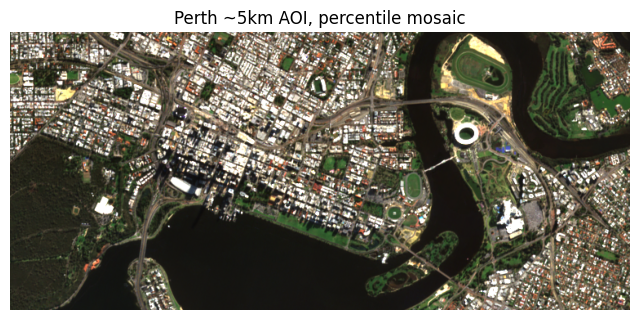

In [3]:
# Display as a stretched RGB composite (B04, B03, B02)
rgb = array.transpose(1, 2, 0).astype(float)
p2, p98 = rgb[rgb > 0].min(), rgb.max() * 0.3
rgb_clipped = ((rgb - p2) / (p98 - p2)).clip(0, 1)
plt.figure(figsize=(8, 6))
plt.imshow(rgb_clipped)
plt.title("Perth ~5km AOI, percentile mosaic")
plt.axis("off")

## 2. Non-square AOI

Unlike cubo (which forces a square `edge_size`), stackstac and therefore `mosaic(bounds=...)` accept arbitrary rectangles. Here's an 8km × 3km strip.

/Users/nick/Documents/Work Code/S2Mosaic/.venv/lib/python3.11/site-packages/omnicloudmask/cloud_mask.py:274: UserWarning: Patch size too large, reducing to 91 and overlap to 45.
  patch_overlap, patch_size = check_patch_size(


Shape: (3, 179, 1230)  (aspect 6.87:1)


(np.float64(-0.5), np.float64(1229.5), np.float64(178.5), np.float64(-0.5))

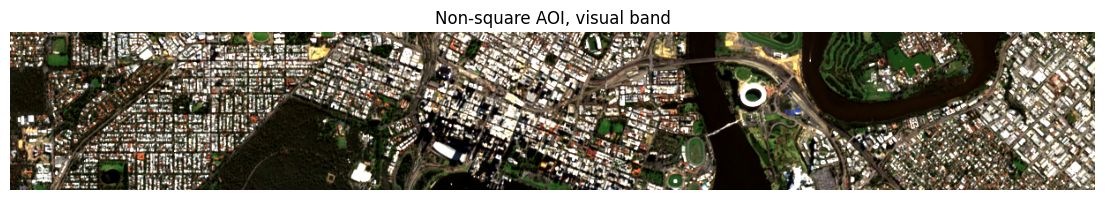

In [4]:
wide_bounds = (115.80, -31.96, 115.93, -31.945)  # ~12km x 1.7km

array, profile = mosaic(
    bounds=wide_bounds,
    start_year=2023,
    start_month=6,
    duration_days=14,
    required_bands=["visual"],  # 3-band uint8 RGB
    mosaic_method="first",
    sort_method="valid_data",
)

print(f"Shape: {array.shape}  (aspect {array.shape[2] / array.shape[1]:.2f}:1)")
plt.figure(figsize=(14, 4))
plt.imshow(array.transpose(1, 2, 0))
plt.title("Non-square AOI, visual band")
plt.axis("off")

## 3. Lower resolution + bilinear resampling

`resolution` is in metres of the output pixel. At 30m, stackstac reads from the nearest COG overview rather than the native 10m file — much less data over the wire. `resampling_method` controls how the source is resampled; `bilinear` is appropriate for continuous reflectance data.

/Users/nick/Documents/Work Code/S2Mosaic/.venv/lib/python3.11/site-packages/omnicloudmask/cloud_mask.py:274: UserWarning: Patch size too large, reducing to 115 and overlap to 57.
  patch_overlap, patch_size = check_patch_size(


Shape: (3, 115, 254)  (vs ~256x256 at 30m for ~5km AOI)
Pixel size: 30.0m


(np.float64(-0.5), np.float64(253.5), np.float64(114.5), np.float64(-0.5))

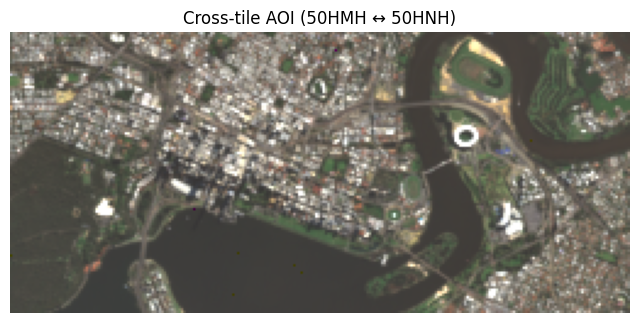

In [10]:
array, profile = mosaic(
    bounds=bounds,  # same Perth AOI as section 1
    start_year=2023,
    start_month=6,
    duration_days=14,
    required_bands=["B04", "B03", "B02"],
    mosaic_method="mean",
    resolution=30,
    resampling_method="bilinear",
    additional_query={"eo:cloud_cover": {"lt": 50}},
)

print(f"Shape: {array.shape}  (vs ~256x256 at 30m for ~5km AOI)")
print(f"Pixel size: {profile['transform'].a}m")

rgb = array.transpose(1, 2, 0).astype(float)
p98 = rgb.max() * 0.5
rgb_clipped = (rgb / p98).clip(0, 1)
plt.figure(figsize=(8, 8))
plt.imshow(rgb_clipped)
plt.title("Cross-tile AOI (50HMH ↔ 50HNH)")
plt.axis("off")

## 4. Cross-MGRS-tile AOI

When bounds span more than one MGRS tile, stackstac pulls scenes from each and reprojects them onto the chosen UTM grid. The result is seamless — no manual stitching.

/Users/nick/Documents/Work Code/S2Mosaic/.venv/lib/python3.11/site-packages/omnicloudmask/cloud_mask.py:274: UserWarning: Significant no-data areas detected. Adjusting patch size to 237px and overlap to 118px to minimize no-data patches.
  patch_overlap, patch_size = check_patch_size(
/Users/nick/Documents/Work Code/S2Mosaic/.venv/lib/python3.11/site-packages/omnicloudmask/cloud_mask.py:274: UserWarning: Patch size too large, reducing to 474 and overlap to 237.
  patch_overlap, patch_size = check_patch_size(


(np.float64(-0.5), np.float64(945.5), np.float64(1108.5), np.float64(-0.5))

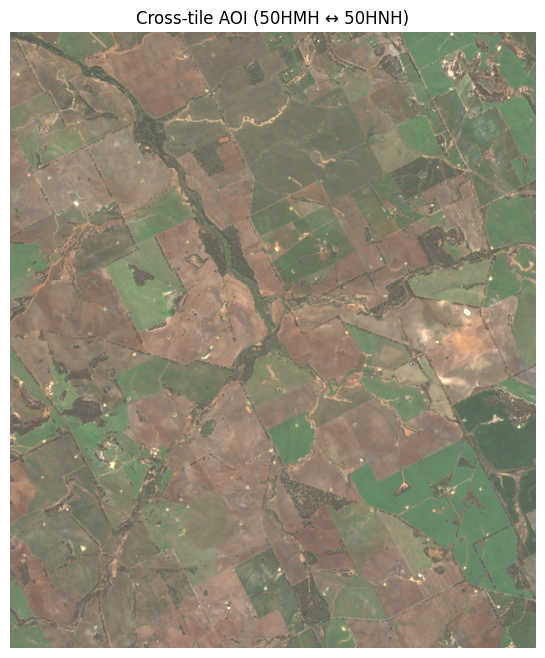

In [11]:
# Crossing the 50HMH / 50HNH boundary (~117 deg E in WA)
cross_bounds = (116.95, -32.05, 117.05, -31.95)

array, profile = mosaic(
    bounds=cross_bounds,
    start_year=2023,
    start_month=6,
    duration_months=1,
    required_bands=["B04", "B03", "B02"],
    mosaic_method="percentile",
    percentile_value=50,
    additional_query={"eo:cloud_cover": {"lt": 50}},
)

rgb = array.transpose(1, 2, 0).astype(float)
p98 = rgb.max() * 0.5
rgb_clipped = (rgb / p98).clip(0, 1)
plt.figure(figsize=(8, 8))
plt.imshow(rgb_clipped)
plt.title("Cross-tile AOI (50HMH ↔ 50HNH)")
plt.axis("off")

## 5. Save to disk

Pass `output_dir` and the GeoTIFF is written with an auto-generated filename. The filename uses the bbox coordinates instead of an MGRS tile ID.

In [7]:
result = mosaic(
    bounds=bounds,
    start_year=2023,
    start_month=6,
    duration_days=14,
    output_dir=Path("output"),
    required_bands=["B04", "B03", "B02"],
    mosaic_method="percentile",
    percentile_value=50,
    additional_query={"eo:cloud_cover": {"lt": 50}},
)
print(f"Saved to: {result}")

/Users/nick/Documents/Work Code/S2Mosaic/.venv/lib/python3.11/site-packages/omnicloudmask/cloud_mask.py:274: UserWarning: Patch size too large, reducing to 171 and overlap to 85.
  patch_overlap, patch_size = check_patch_size(


Saved to: output/bounds_115.8300_-31.9700_115.9100_-31.9400_2023-06-01_to_2023-06-15_valid_data_percentile_B04_B03_B02.tif
